# Gabor Noise Renderer - Step by Step Visualization

This notebook walks through `gabor_noise_renderer.py` one tensor at a time and
visualizes every matrix/tensor produced at each stage, so you can see exactly how
a set of Gabor primitives is turned into a rendered image.

We use a small, hand-picked set of primitives so the intermediate tensors are small
enough to actually look at (not just 500x512x512 blobs).

Reference code: `gabor_noise_renderer.py`:

- `_build_object_space_grid` - builds the NDC grid and Gaussian envelope
- `_render_primitive_chunk` - builds the Gabor patch (grating x envelope)
- `render_gabor_image` - places patches in world space and sums them
- `render` - end to end

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Force the renderer module to build everything on CPU so we can inspect tensors
# as numpy arrays without pulling them off the GPU.
import gabor_noise_renderer as gnr

def force_cpu():
    gnr.device = torch.device('cpu')
    global device
    device = torch.device('cpu')

force_cpu()

from gabor_noise_renderer import (
    GaborModel,
    _build_object_space_grid,
    _render_primitive_chunk,
    render_gabor_image,
)

torch.manual_seed(0)
np.random.seed(0)

print("device:", device)

device: cpu


## 1. Configure a tiny example

We use a small kernel (64x64) and just 3 primitives so every tensor is inspectable.

In [2]:
KERNEL_SIZE = 64          # small so tensors are visible
PRIMITIVE_NUM = 4         # small so intermediates are readable
OBJECT_SPACE_RANGE = 10.0

# The real renderer samples 'colors' from the ground-truth image at each primitive's
# center. We feed a simple RGB gradient as a stand-in GT image.
def make_gt_gradient(k):
    yy, xx = np.mgrid[0:k, 0:k] / (k - 1)
    r = np.expand_dims(xx, -1)
    g = np.expand_dims(yy, -1)
    b = np.expand_dims(np.ones((k, k)) * 0.3, -1)
    return np.concatenate([r, g, b], axis=-1)

gt_image_array = make_gt_gradient(KERNEL_SIZE)

model = GaborModel()
model.create_points(primitive_num=PRIMITIVE_NUM, kernel_size=KERNEL_SIZE, gt_image_array=gt_image_array)

batch = model._means.shape[0]
print("number of primitives:", batch)
for name in ("means", "scales", "rotations", "frequencies", "colors", "colors2", "opacities"):
    t = getattr(model, "_" + name).data
    print(f"{name:12s} shape={tuple(t.shape)} range=[{t.min().item():.2f}, {t.max().item():.2f}]")
    print("   ", t.detach().cpu().numpy().tolist())

number of primitives: 4
means        shape=(4, 2) range=[-0.82, 0.79]
    [[-0.007486820220947266, 0.5364435911178589], [-0.8230451345443726, -0.7359390258789062], [-0.3851543664932251, 0.26815736293792725], [-0.019813179969787598, 0.7928894758224487]]
scales       shape=(4, 2) range=[0.66, 1.42]
    [[1.1976675987243652, 1.300011396408081], [0.6610294580459595, 0.7822685837745667], [1.1816085577011108, 1.415194034576416], [0.8970999121665955, 1.374155879020691]]
rotations    shape=(4,) range=[0.11, 2.99]
    [1.3176101446151733, 1.737008810043335, 2.993115186691284, 0.11361514031887054]
frequencies  shape=(4, 2) range=[0.52, 1.13]
    [[0.955627977848053, 1.1323063373565674], [0.8488934636116028, 0.9017173051834106], [0.5223257541656494, 0.6688589453697205], [0.7938884496688843, 1.018521785736084]]
colors       shape=(4, 3) range=[0.08, 0.90]
    [[0.7777777910232544, 0.4920634925365448, 0.30000001192092896], [0.1269841343164444, 0.0793650820851326, 0.30000001192092896], [0.6349206566

## 2. Build the object-space grid

`_build_object_space_grid` creates:

1. `xx`, `yy` - NDC coordinates warped to object space `[-1,1] * OBJECT_SPACE_RANGE`
2. `gaussian_strength` - the Gaussian envelope `exp(-(x^2+y^2)/2)`

`xx` and `yy` have shape `(1, kernel, kernel, 1)`, the envelope `(1, kernel, kernel, 1)`.

xx shape: (1, 64, 64, 1) | yy shape: (1, 64, 64, 1)
gaussian_strength shape: (1, 64, 64, 1)


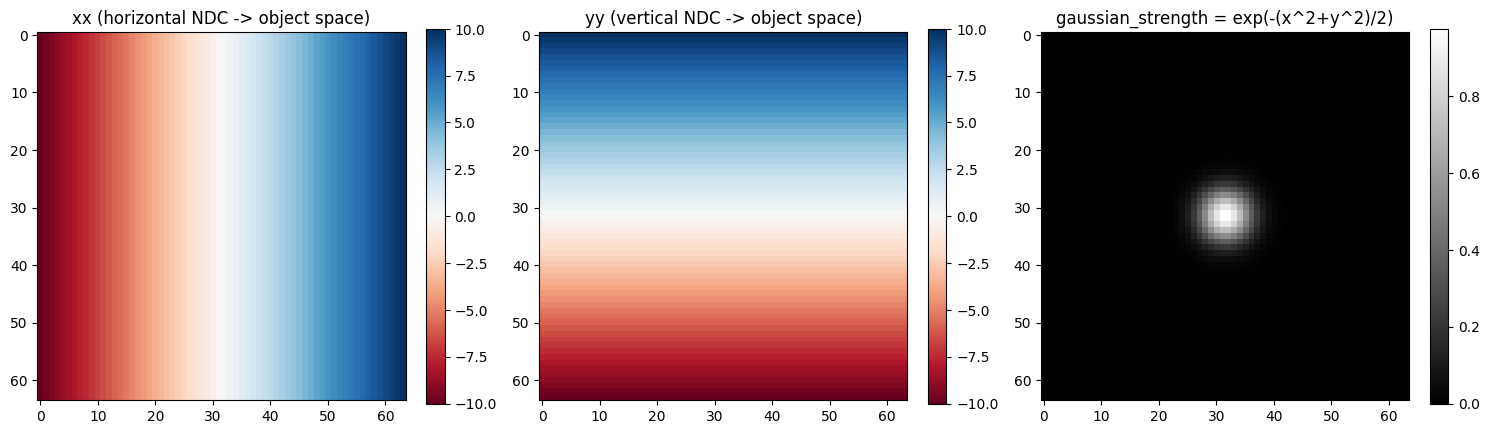

corner sample  xx[0,0,0,0] = -10.0
center sample  xx[0,32,32,0] = 0.15872955322265625


In [3]:
xx, yy, gaussian_strength = _build_object_space_grid(KERNEL_SIZE, device)
print("xx shape:", tuple(xx.shape), "| yy shape:", tuple(yy.shape))
print("gaussian_strength shape:", tuple(gaussian_strength.shape))

# Visualize the coordinate grids as images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(xx[0, :, :, 0].numpy(), cmap='RdBu')
axes[0].set_title("xx (horizontal NDC -> object space)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(yy[0, :, :, 0].numpy(), cmap='RdBu')
axes[1].set_title("yy (vertical NDC -> object space)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(gaussian_strength[0, :, :, 0].numpy(), cmap='gray')
axes[2].set_title("gaussian_strength = exp(-(x^2+y^2)/2)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

print("corner sample  xx[0,0,0,0] =", xx[0,0,0,0].item())
print("center sample  xx[0,32,32,0] =", xx[0,32,32,0].item())

## 3. The carrier grating (harmonic) for a single primitive

For each primitive the code builds two complementary cosine gratings from its
frequency `f = (fx, fy)`:

- `harmonic1 = (1 + cos(2*pi*(fx*x + fy*y))) / 2`
- `harmonic2 = (1 - cos(2*pi*(fx*x + fy*y))) / 2`

These are the "stripes". Let's inspect them for the first primitive.

primitive 0 frequency: [0.955627977848053, 1.1323063373565674]


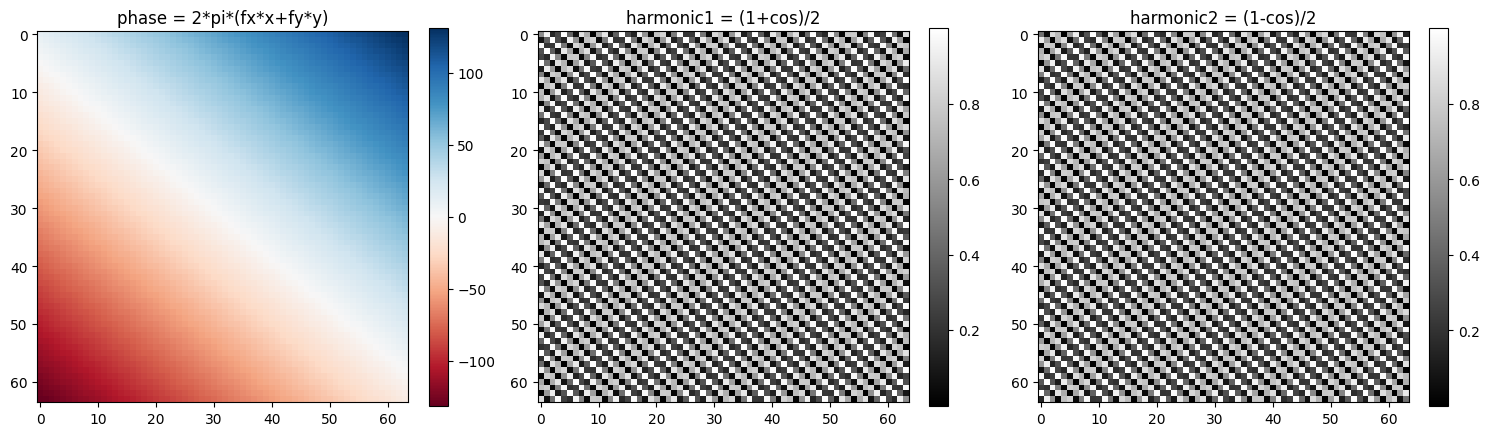

max |harmonic1 + harmonic2 - 1| = 0.0


In [4]:
i = 0  # which primitive to inspect
freq = model._frequencies.data[i]
print("primitive", i, "frequency:", freq.tolist())

fx, fy = freq[0].item(), freq[1].item()

phase = 2 * np.pi * (fx * xx[0, :, :, 0].numpy() + fy * yy[0, :, :, 0].numpy())
harmonic1 = (1 + np.cos(phase)) / 2
harmonic2 = (1 - np.cos(phase)) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(phase, cmap='RdBu'); axes[0].set_title("phase = 2*pi*(fx*x+fy*y)"); plt.colorbar(im, ax=axes[0], fraction=0.046)
im = axes[1].imshow(harmonic1, cmap='gray'); axes[1].set_title("harmonic1 = (1+cos)/2"); plt.colorbar(im, ax=axes[1], fraction=0.046)
im = axes[2].imshow(harmonic2, cmap='gray'); axes[2].set_title("harmonic2 = (1-cos)/2"); plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

# Sanity check: the two harmonics should sum to 1 at every pixel
print("max |harmonic1 + harmonic2 - 1| =", np.abs(harmonic1 + harmonic2 - 1).max())

## 4. Tint the gratings with colors

Colors are `[R,G,B]` per primitive. The two gratings are multiplied by two colors:

- `harmonic_with_color1 = colors * harmonic1`
- `harmonic_with_color2 = colors2 * harmonic2`

So along the stripes the image blends between `colors` and `colors2`.

colors  (c1): [0.7777778 0.4920635 0.3      ]
colors2 (c2): [0. 0. 0.]


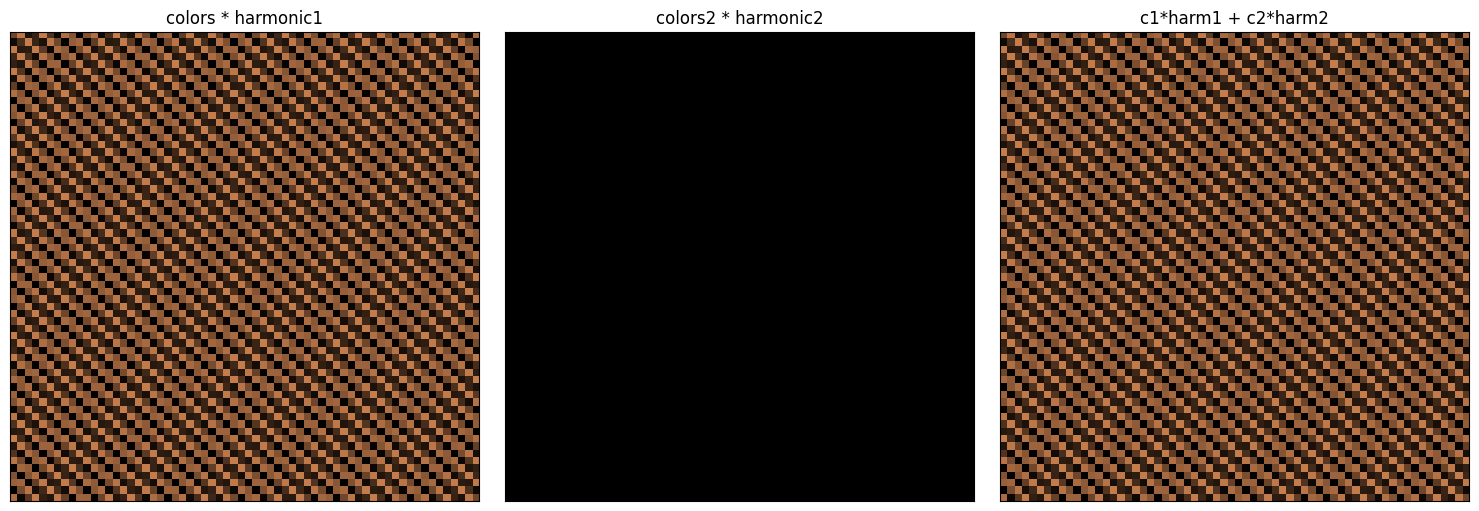

In [5]:
c1 = model._colors.data[i].numpy()
c2 = model._colors2.data[i].numpy()
print("colors  (c1):", c1)
print("colors2 (c2):", c2)

# Per-channel multiplication: (H, W, 1) * (3,) -> (H, W, 3)
hwc1 = harmonic1[..., None] * c1
hwc2 = harmonic2[..., None] * c2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(hwc1.clip(0, 1)); axes[0].set_title("colors * harmonic1")
axes[1].imshow(hwc2.clip(0, 1)); axes[1].set_title("colors2 * harmonic2")
axes[2].imshow((hwc1 + hwc2).clip(0, 1)); axes[2].set_title("c1*harm1 + c2*harm2")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Combine into the full primitive: opacity * gaussian * grating

Now everything comes together inside the Gaussian window:

`primitives = opacity * gaussian_strength * (c1*harm1 + c2*harm2)`

This one tensor, per primitive, is the Gabor patch before it is placed/scaled/rotated.

opacity of primitive 0 : 1.0


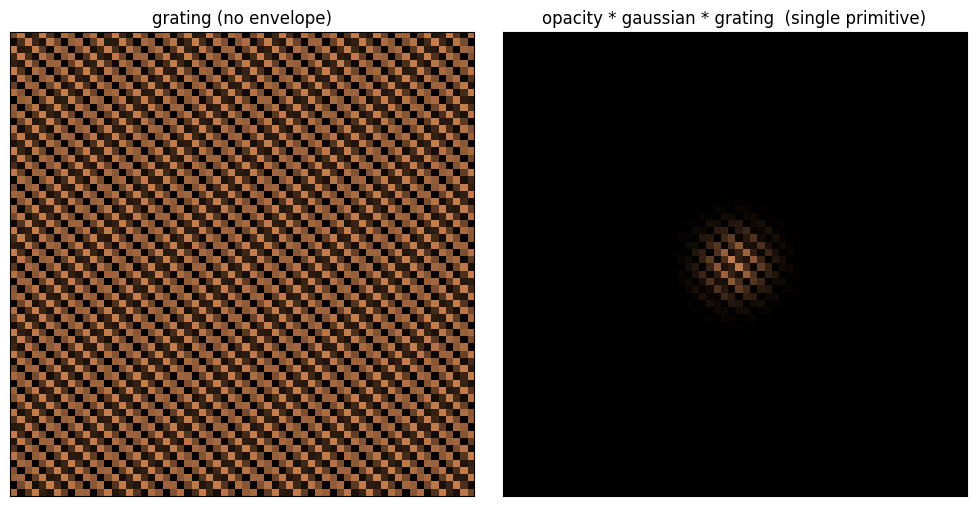

primitive tensor range: 0.0 - 0.753


In [6]:
opacity = model._opacities.data[i].item()
print("opacity of primitive", i, ":", opacity)

# replicate the exact math the renderer does (per-batch) onto the (H,W) grid:
prim_color = (harmonic1[..., None] * c1 + harmonic2[..., None] * c2)
primitive_unnormalized = opacity * gaussian_strength[0, :, :, 0].numpy()[..., None] * prim_color

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow((prim_color).clip(0,1)); axes[0].set_title("grating (no envelope)")
axes[1].imshow(primitive_unnormalized.clip(0,1)); axes[1].set_title("opacity * gaussian * grating  (single primitive)")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("primitive tensor range:", primitive_unnormalized.min().round(3), "-", primitive_unnormalized.max().round(3))

## 6. The affine transform (scale + rotation + translation)

Each primitive has `scales` (sx, sy), `rotations` (theta) and a `means` center.
The renderer builds a 2x3 affine matrix:

```
[sx*cos, -sx*sin | tx]
[sy*sin,  sy*cos | ty]
```

and uses `F.affine_grid` + `F.grid_sample` to warp the patch into world space. Let's
replicate that per primitive.

prims_stack shape (N,H,W,3): (4, 64, 64, 3)

--- affine matrix primitive 0 ---
[[ 0.30000356 -1.1594851  -0.6197523 ]
 [ 1.258566    0.32563964  0.18410996]]

--- affine matrix primitive 1 ---
[[-0.10936615 -0.6519194   0.3897597 ]
 [ 0.7714877  -0.12942494  0.73021805]]

--- affine matrix primitive 2 ---
[[-1.1686078  -0.17479834 -0.49696788]
 [ 0.20935324 -1.3996233  -0.29468596]]

--- affine matrix primitive 3 ---
[[ 0.89131606 -0.10170499 -0.06298101]
 [ 0.15578924  1.3652964   1.0856158 ]]


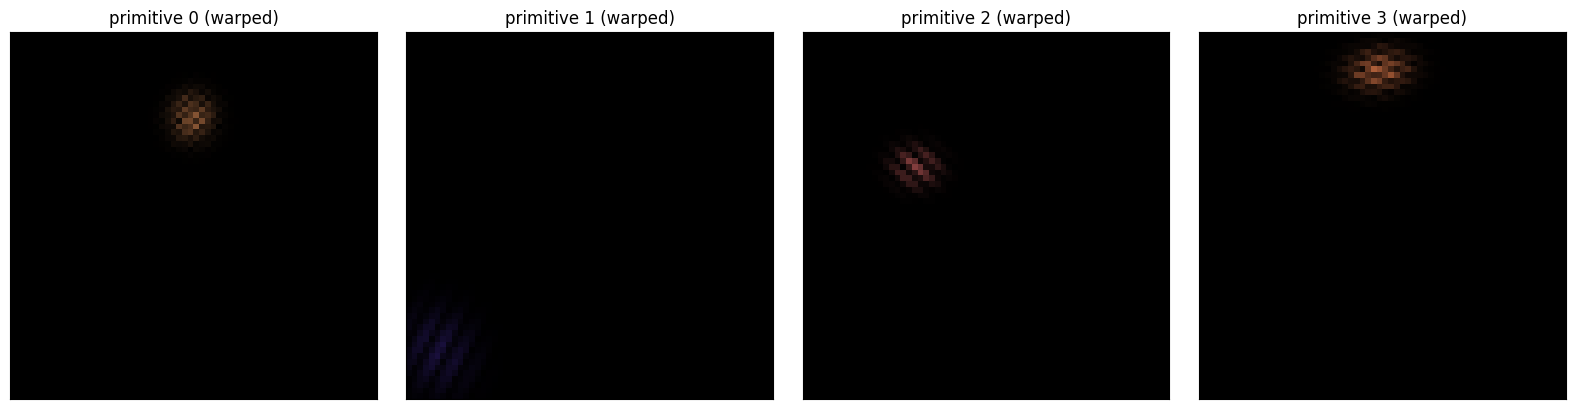

In [7]:
means = model._means.data
scales = model._scales.data
rotations = model._rotations.data

# Rebuild all primitives stacked like the renderer's chunk function, but WITHOUT
# the sum, so we can look at each one separately.
batch = PRIMITIVE_NUM
freq_t = model._frequencies.data.view(batch, 1, 1, 2)
fx_t, fy_t = freq_t[..., :1], freq_t[..., 1:]
p = 2 * np.pi * (fx_t * xx + fy_t * yy)
h1 = (1 + torch.cos(p)) / 2
h2 = (1 - torch.cos(p)) / 2

c = model._colors.data.view(batch, 1, 1, 3)
c2v = model._colors2.data.view(batch, 1, 1, 3)
h_w_c1 = c * h1
h_w_c2 = c2v * h2
opac = model._opacities.data.view(batch, 1, 1, 1)
prims_stack = opac * gaussian_strength * (h_w_c1 + h_w_c2)
print("prims_stack shape (N,H,W,3):", tuple(prims_stack.shape))

# Build affine matrices
aff = torch.zeros((batch, 2, 3), dtype=torch.float32)
sx, sy = scales[:, 0], scales[:, 1]
ct = torch.cos(rotations); st = torch.sin(rotations)
aff[:, 0, 0] = sx * ct
aff[:, 0, 1] = -sx * st
aff[:, 1, 0] = sy * st
aff[:, 1, 1] = sy * ct
aff[:, 0, 2] = -means[:, 0] * sx * ct + means[:, 1] * (-sx * st)
aff[:, 1, 2] = -means[:, 0] * sy * st + means[:, 1] * (sy * ct)

for idx in range(batch):
    print("\n--- affine matrix primitive", idx, "---")
    print(aff[idx].detach().numpy())

# Warp each primitive separately with grid_sample
grid = F.affine_grid(aff, size=(batch, 3, KERNEL_SIZE, KERNEL_SIZE), align_corners=False)
warped = prims_stack.permute(0, 3, 1, 2).contiguous()
warped = F.grid_sample(warped, grid, align_corners=False)
warped = warped.permute(0, 2, 3, 1)

fig, axes = plt.subplots(1, batch, figsize=(4*batch, 4))
if batch == 1:
    axes = [axes]
for idx, ax in enumerate(axes):
    ax.imshow(warped[idx].detach().clip(0,1).numpy())
    ax.set_title(f"primitive {idx} (warped)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Sum all primitives -> the rendered image

This is exactly what `render_gabor_image` does: sum the warped primitives together
and clamp to `[0, 1]`.

render_gabor_image output shape: (64, 64, 3)
output range: 0.0 - 0.6736012697219849


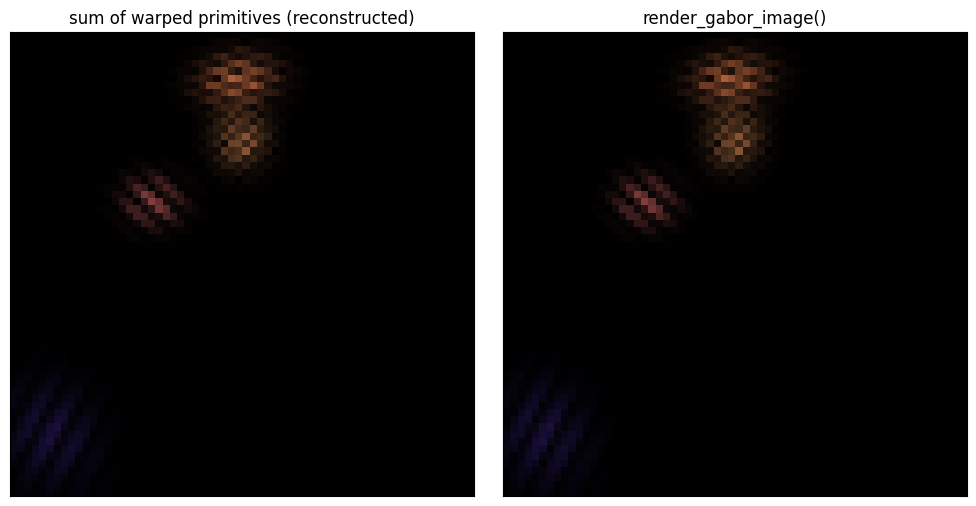

max abs diff vs render_gabor_image: 0.0


In [8]:
# For a fair comparison, reuse the exact renderer entry point:
full = render_gabor_image(
    kernel_size=KERNEL_SIZE,
    means=model._means,
    frequencies=model._frequencies,
    colors=model._colors,
    colors2=model._colors2,
    opacities=model._opacities,
    scales=model._scales,
    rotations=model._rotations,
    device=device,
)
print("render_gabor_image output shape:", tuple(full.shape))
print("output range:", full.min().item(), "-", full.max().item())

summed = warped.sum(dim=0)
summed = torch.clamp(summed, min=0.0, max=1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(summed.detach().numpy())
axes[0].set_title("sum of warped primitives (reconstructed)")
axes[1].imshow(full.detach().numpy())
axes[1].set_title("render_gabor_image()")
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

diff = (summed - full).abs().max().item()
print("max abs diff vs render_gabor_image:", diff)

## 8. Visualization helper: inspect every tensor at once

A compact table of each tensor's shape, dtype and value range at every stage so you
can quickly scan the whole pipeline.

In [9]:
def describe(name, t):
    a = t.detach().cpu().numpy()
    print(f"{name:28s} shape={str(a.shape):25s} dtype={a.dtype} range=[{a.min():+.4f}, {a.max():+.4f}]")

print("=== MODEL PARAMETERS (per primitive) ===")
describe("means          ", model._means)
describe("colors         ", model._colors)
describe("colors2        ", model._colors2)
describe("frequencies    ", model._frequencies)
describe("opacities      ", model._opacities)
describe("scales         ", model._scales)
describe("rotations      ", model._rotations)

print("\n=== OBJECT SPACE GRID ===")
describe("xx             ", xx)
describe("yy             ", yy)
describe("gaussian_strength", gaussian_strength)

print("\n=== PER-PRIMITIVE STACK ===")
describe("frequency view  ", freq_t)
describe("phase 2pi(fxx+fyy)", p)
describe("harmonic1       ", h1)
describe("harmonic2       ", h2)
describe("c1*harm1        ", h_w_c1)
describe("c2*harm2        ", h_w_c2)
describe("c1*h1+c2*h2     ", h_w_c1 + h_w_c2)
describe("primitive (before warp)", prims_stack)

print("\n=== TRANSFORM ===")
describe("affine_grid     ", grid)
describe("warped primitives", warped)

print("\n=== OUTPUT ===")
describe("summed image    ", summed)
describe("final clamped   ", full)

=== MODEL PARAMETERS (per primitive) ===
means                        shape=(4, 2)                    dtype=float32 range=[-0.8230, +0.7929]
colors                       shape=(4, 3)                    dtype=float32 range=[+0.0794, +0.9048]
colors2                      shape=(4, 3)                    dtype=float32 range=[+0.0000, +0.0000]
frequencies                  shape=(4, 2)                    dtype=float32 range=[+0.5223, +1.1323]
opacities                    shape=(4,)                      dtype=float32 range=[+1.0000, +1.0000]
scales                       shape=(4, 2)                    dtype=float32 range=[+0.6610, +1.4152]
rotations                    shape=(4,)                      dtype=float32 range=[+0.1136, +2.9931]

=== OBJECT SPACE GRID ===
xx                           shape=(1, 64, 64, 1)            dtype=float32 range=[-10.0000, +10.0000]
yy                           shape=(1, 64, 64, 1)            dtype=float32 range=[-10.0000, +10.0000]
gaussian_strength           

## 9. How each weight is interpreted (a readable cheat-sheet)

Every `nn.Parameter` in `GaborModel` has a concrete geometric meaning. Here we
interpret each one for a single primitive with real numbers, so the shapes we saw
above map onto something you can reason about. Where it lives in
`gabor_noise_renderer.py` is noted inline.

In [10]:
import numpy as np
import torch

def show_meaning(idx):
    m = model._means.data[idx].cpu().numpy()
    s = model._scales.data[idx].cpu().numpy()
    r = float(np.degrees(model._rotations.data[idx].cpu().numpy()))
    f = model._frequencies.data[idx].cpu().numpy()
    c = model._colors.data[idx].cpu().numpy()
    c2 = model._colors2.data[idx].cpu().numpy()
    o = float(model._opacities.data[idx].cpu().numpy())

    print(f"=== primitive {idx} ===")
    print(f"means       {m}   -> NDC center of the patch on the [-1,1] canvas")
    px = int(KERNEL_SIZE*(m[0]+1)/2); py = int(KERNEL_SIZE*(m[1]+1)/2)
    print(f"  -> pixel coords: ({px}, {py})")
    print(f"scales      {s}   -> stretches the patch along x / y (object-space units)")
    print(f"rotations   {r:6.1f} deg   -> rotates the patch around its center")
    print(f"frequencies {f}   -> carrier cycles along x / y within the patch")
    print(f"colors      {c}   -> RGB tint of the 'bright' stripes  (colors*harm1)")
    print(f"colors2     {c2}  -> RGB tint of the 'dim'   stripes  (colors2*harm2)")
    print(f"opacities   {o}   -> alpha multiplier applied to the whole patch")
    print()

show_meaning(0)
show_meaning(1)

=== primitive 0 ===
means       [-0.00748682  0.5364436 ]   -> NDC center of the patch on the [-1,1] canvas
  -> pixel coords: (31, 49)
scales      [1.1976676 1.3000114]   -> stretches the patch along x / y (object-space units)
rotations     75.5 deg   -> rotates the patch around its center
frequencies [0.955628  1.1323063]   -> carrier cycles along x / y within the patch
colors      [0.7777778 0.4920635 0.3      ]   -> RGB tint of the 'bright' stripes  (colors*harm1)
colors2     [0. 0. 0.]  -> RGB tint of the 'dim'   stripes  (colors2*harm2)
opacities   1.0   -> alpha multiplier applied to the whole patch

=== primitive 1 ===
means       [-0.82304513 -0.735939  ]   -> NDC center of the patch on the [-1,1] canvas
  -> pixel coords: (5, 8)
scales      [0.66102946 0.7822686 ]   -> stretches the patch along x / y (object-space units)
rotations     99.5 deg   -> rotates the patch around its center
frequencies [0.84889346 0.9017173 ]   -> carrier cycles along x / y within the patch
colors  

### 9.1 `means` - where the patch sits

`means` is a unit-square NDC coordinate in `[-1, 1]`. The renderer samples the
"color at this pixel" from the GT image (`gabor_noise_renderer.py:44-48`) and then
places the whole patch there via the affine matrix's translation term
(`gabor_noise_renderer.py:190-191`). Here we show the mapping from NDC to image
pixel space and which GT color gets sampled.

In [11]:
def ndc_to_pixel(ndc, kernel):
    # Same formula used to sample GT colors in create_points
    return int(kernel * ((ndc + 1.0) / 2))

print(f"{'ndc (x,y)':<22}{'pixel (row,col)':<20}{'sampled GT color'}")
for i in range(batch):
    m = model._means.data[i].cpu().numpy()
    row = ndc_to_pixel(m[1], KERNEL_SIZE)  # row
    col = ndc_to_pixel(m[0], KERNEL_SIZE)  # col
    gt_rgb = gt_image_array[row, col]
    print(f"({m[0]:+.3f}, {m[1]:+.3f})     ({row:3d}, {col:3d})        {np.round(gt_rgb, 3)}")

print()
print("model.colors (stored during create_points):")
print(model._colors.data.cpu().numpy().round(3))

ndc (x,y)             pixel (row,col)     sampled GT color
(-0.007, +0.536)     ( 49,  31)        [0.492 0.778 0.3  ]
(-0.823, -0.736)     (  8,   5)        [0.079 0.127 0.3  ]
(-0.385, +0.268)     ( 40,  19)        [0.302 0.635 0.3  ]
(-0.020, +0.793)     ( 57,  31)        [0.492 0.905 0.3  ]

model.colors (stored during create_points):
[[0.778 0.492 0.3  ]
 [0.127 0.079 0.3  ]
 [0.635 0.302 0.3  ]
 [0.905 0.492 0.3  ]]


### 9.2 `scales` - stretch factor

`scales = (sx, sy)` are the diagonal of the affine matrix (`gabor_noise_renderer.py:183-189`),
combined with rotation. `sx=1, sy=1` gives a unit patch in object space; larger values
stretch it. Let's visualize the same primitive at three different scales.

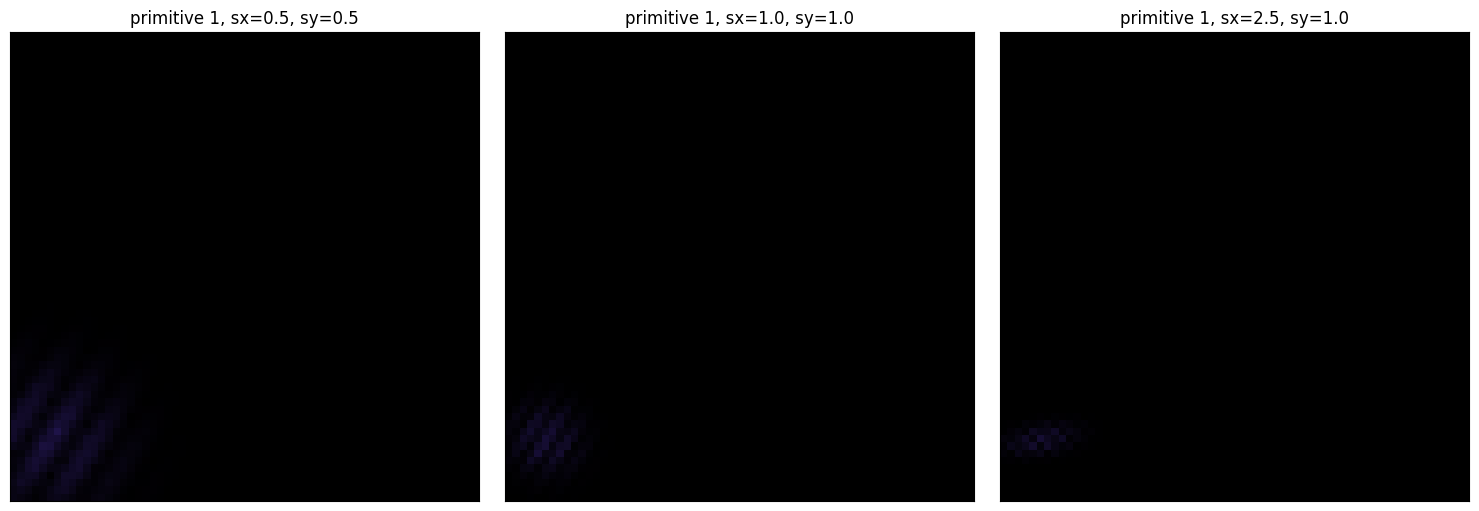

In [12]:
def render_single_at(idx, sx, sy):
    m = model._means.data[idx:idx+1].clone()
    f = model._frequencies.data[idx:idx+1].clone()
    c = model._colors.data[idx:idx+1].clone()
    c2 = model._colors2.data[idx:idx+1].clone()
    o = model._opacities.data[idx:idx+1].clone()
    s = torch.tensor([[sx, sy]], dtype=torch.float32)
    r = model._rotations.data[idx:idx+1].clone()
    return render_gabor_image(KERNEL_SIZE, m, f, c, c2, o, s, r, device)

idx = 1
variations = [("sx=0.5, sy=0.5", 0.5, 0.5),
              ("sx=1.0, sy=1.0", 1.0, 1.0),
              ("sx=2.5, sy=1.0", 2.5, 1.0)]

fig, axes = plt.subplots(1, len(variations), figsize=(5*len(variations), 5))
for ax, (lab, sx, sy) in zip(axes, variations):
    img = render_single_at(idx, sx, sy).clip(0, 1).detach().numpy()
    ax.imshow(img)
    ax.set_title(f"primitive {idx}, {lab}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 9.3 `rotations` - spinning the patch

`rotations` is the angle (radians, range `[0, pi]` at init) that builds the affine
rotation terms `cos`/`sin` (`gabor_noise_renderer.py:184-185`). Same patch, three angles.

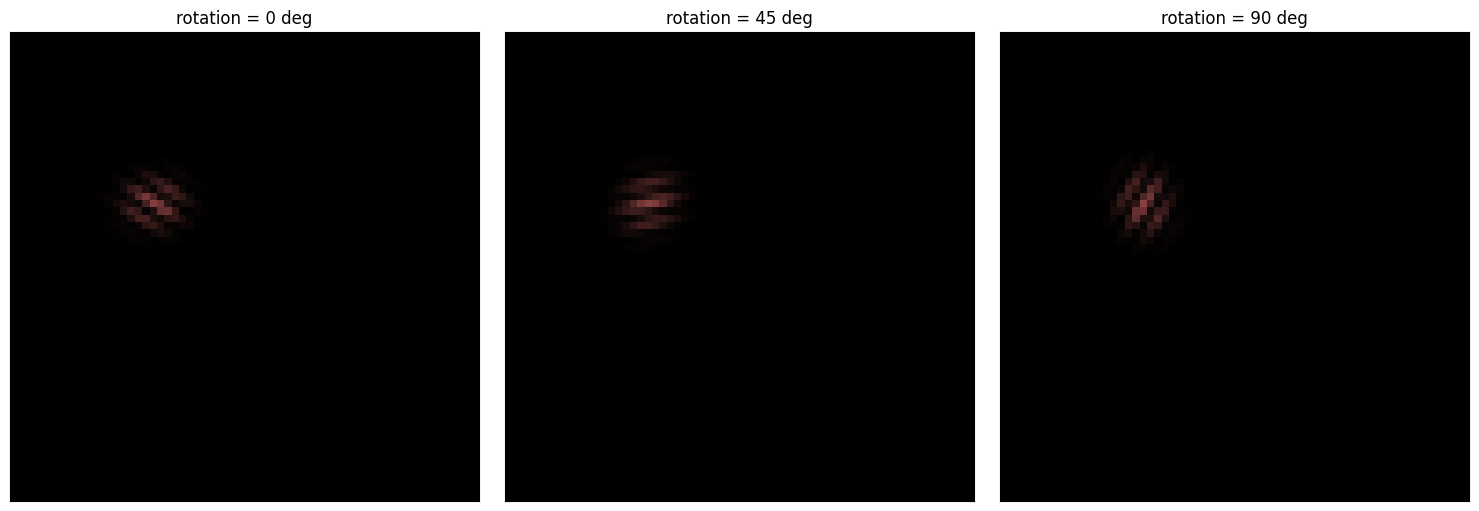

In [13]:
def render_single_rot(idx, theta_deg):
    m = model._means.data[idx:idx+1].clone()
    f = model._frequencies.data[idx:idx+1].clone()
    c = model._colors.data[idx:idx+1].clone()
    c2 = model._colors2.data[idx:idx+1].clone()
    o = model._opacities.data[idx:idx+1].clone()
    s = model._scales.data[idx:idx+1].clone()
    r = torch.tensor([np.radians(theta_deg)], dtype=torch.float32)
    return render_gabor_image(KERNEL_SIZE, m, f, c, c2, o, s, r, device)

idx = 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, angle in zip(axes, (0, 45, 90)):
    img = render_single_rot(idx, angle).clip(0, 1).detach().numpy()
    ax.imshow(img)
    ax.set_title(f"rotation = {angle} deg")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 9.4 `frequencies` - the carrier grating

`frequencies = (fx, fy)` are the number of grating cycles per object-space unit in
each direction; they drive the `phase = 2*pi*(fx*x + fy*y)` term
(`gabor_noise_renderer.py:164-165`). Higher frequency = tighter stripes.

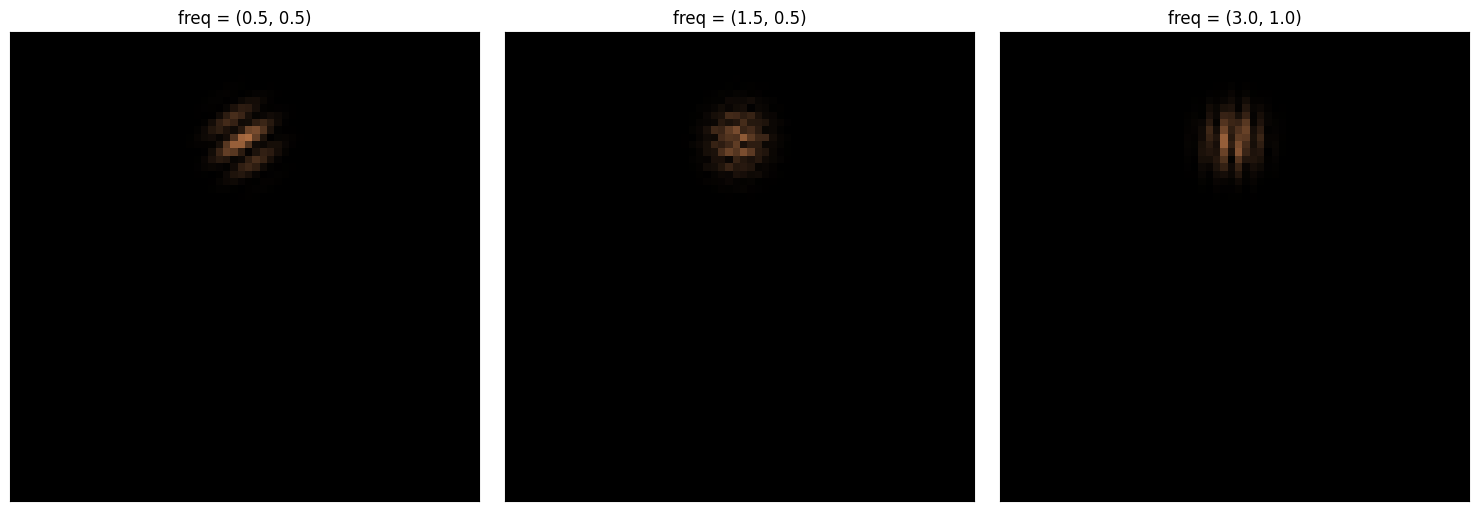

In [14]:
def render_single_freq(idx, fx, fy):
    m = model._means.data[idx:idx+1].clone()
    f = torch.tensor([[fx, fy]], dtype=torch.float32)
    c = model._colors.data[idx:idx+1].clone()
    c2 = model._colors2.data[idx:idx+1].clone()
    o = model._opacities.data[idx:idx+1].clone()
    s = model._scales.data[idx:idx+1].clone()
    r = model._rotations.data[idx:idx+1].clone()
    return render_gabor_image(KERNEL_SIZE, m, f, c, c2, o, s, r, device)

idx = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (fx, fy) in zip(axes, [(0.5, 0.5), (1.5, 0.5), (3.0, 1.0)]):
    img = render_single_freq(idx, fx, fy).clip(0, 1).detach().numpy()
    ax.imshow(img)
    ax.set_title(f"freq = ({fx}, {fy})")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 9.5 `colors` and `colors2` - the two stripe colors

The grating oscillates between these two RGB endpoints. `colors` paints the bright
crests (`* harmonic1`) and `colors2` the dark troughs (`* harmonic2`). Two primitives
with identical geometry but different color pairs show how tint drives appearance.

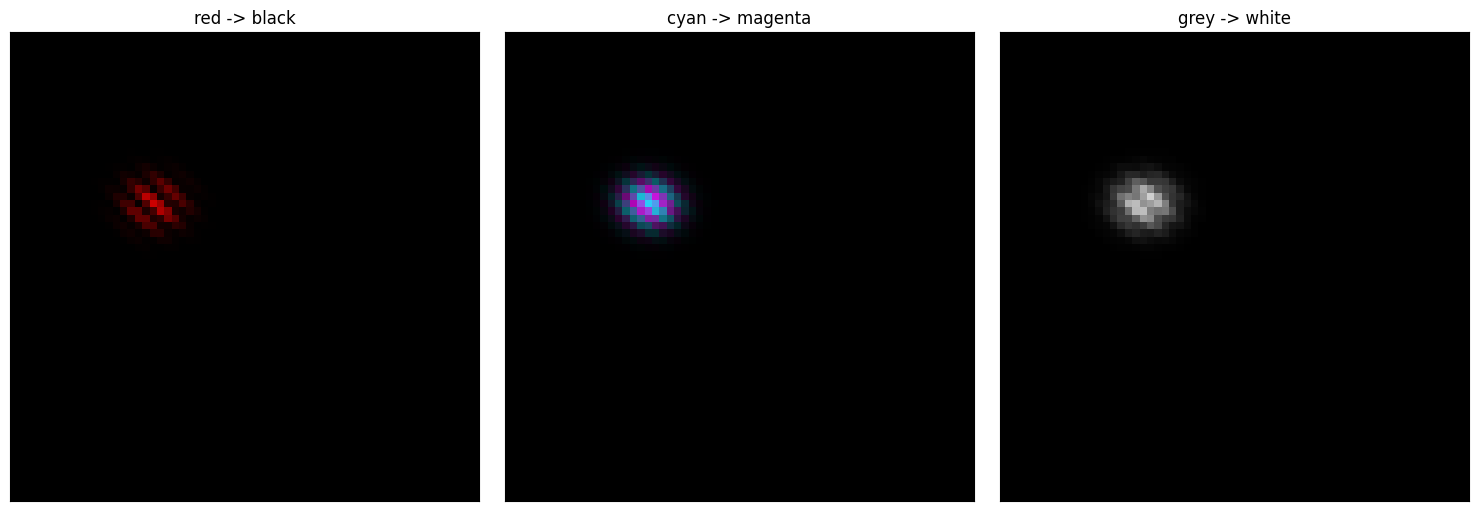

In [15]:
def render_with_colors(idx, c1, c2):
    m = model._means.data[idx:idx+1].clone()
    f = model._frequencies.data[idx:idx+1].clone()
    co = torch.tensor([c1], dtype=torch.float32)
    c2v = torch.tensor([c2], dtype=torch.float32)
    o = model._opacities.data[idx:idx+1].clone()
    s = model._scales.data[idx:idx+1].clone()
    r = model._rotations.data[idx:idx+1].clone()
    return render_gabor_image(KERNEL_SIZE, m, f, co, c2v, o, s, r, device)

idx = 2
pairs = [("red -> black", [1,0,0], [0,0,0]),
         ("cyan -> magenta", [0,1,1], [1,0,1]),
         ("grey -> white", [0.5,0.5,0.5], [1,1,1])]
fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs), 5))
for ax, (lab, c1, c2) in zip(axes, pairs):
    img = render_with_colors(idx, c1, c2).clip(0, 1).detach().numpy()
    ax.imshow(img)
    ax.set_title(lab)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 9.6 `opacities` - overall strength

`opacities` is a single scalar that scales the entire patch (the leading factor in
`gabor_noise_renderer.py:179`). Since the renderer clamps the final image to
`[0, 1]`, opacity controls how saturated/visible the patch is. Same patch, three opacities.

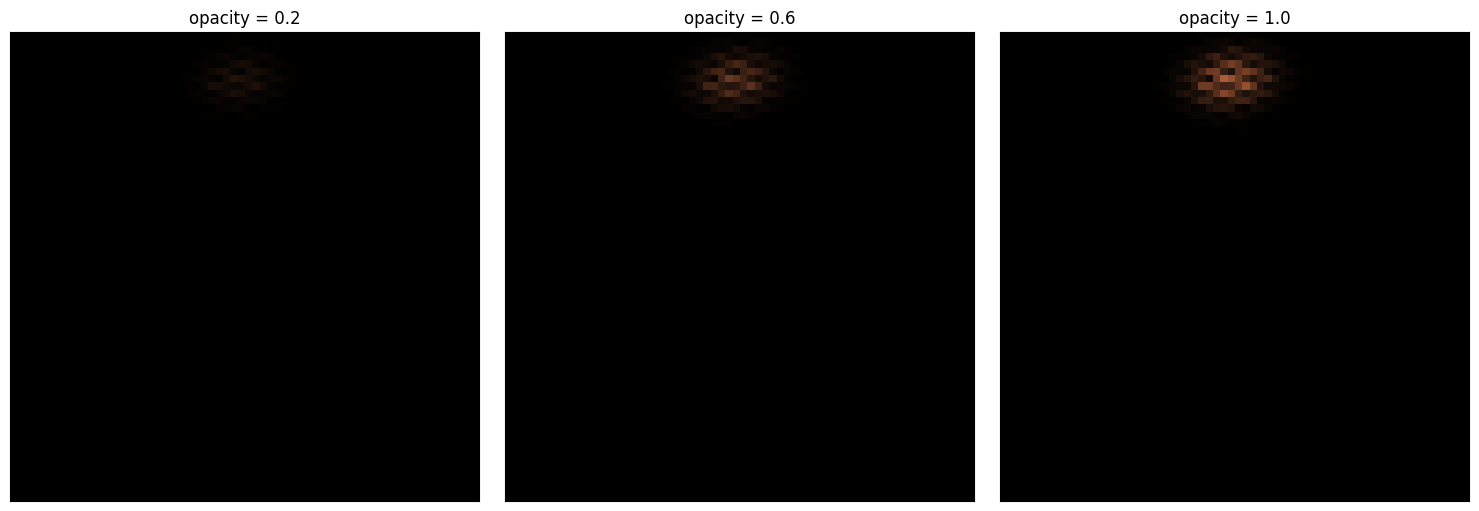

In [16]:
def render_single_opa(idx, opa):
    m = model._means.data[idx:idx+1].clone()
    f = model._frequencies.data[idx:idx+1].clone()
    c = model._colors.data[idx:idx+1].clone()
    c2 = model._colors2.data[idx:idx+1].clone()
    o = torch.tensor([opa], dtype=torch.float32)
    s = model._scales.data[idx:idx+1].clone()
    r = model._rotations.data[idx:idx+1].clone()
    return render_gabor_image(KERNEL_SIZE, m, f, c, c2, o, s, r, device)

idx = 3
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (lab, opa) in zip(axes, [("opacity = 0.2", 0.2), ("opacity = 0.6", 0.6), ("opacity = 1.0", 1.0)]):
    img = render_single_opa(idx, opa).clip(0, 1).detach().numpy()
    ax.imshow(img)
    ax.set_title(lab)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 9.7 Putting it together: one parameter changed at a time

To make the interpretation concrete, here is a single primitive where we flip each
weight one at a time from its stored value to an arbitrary alternate, showing how
each knob independently changes the look.

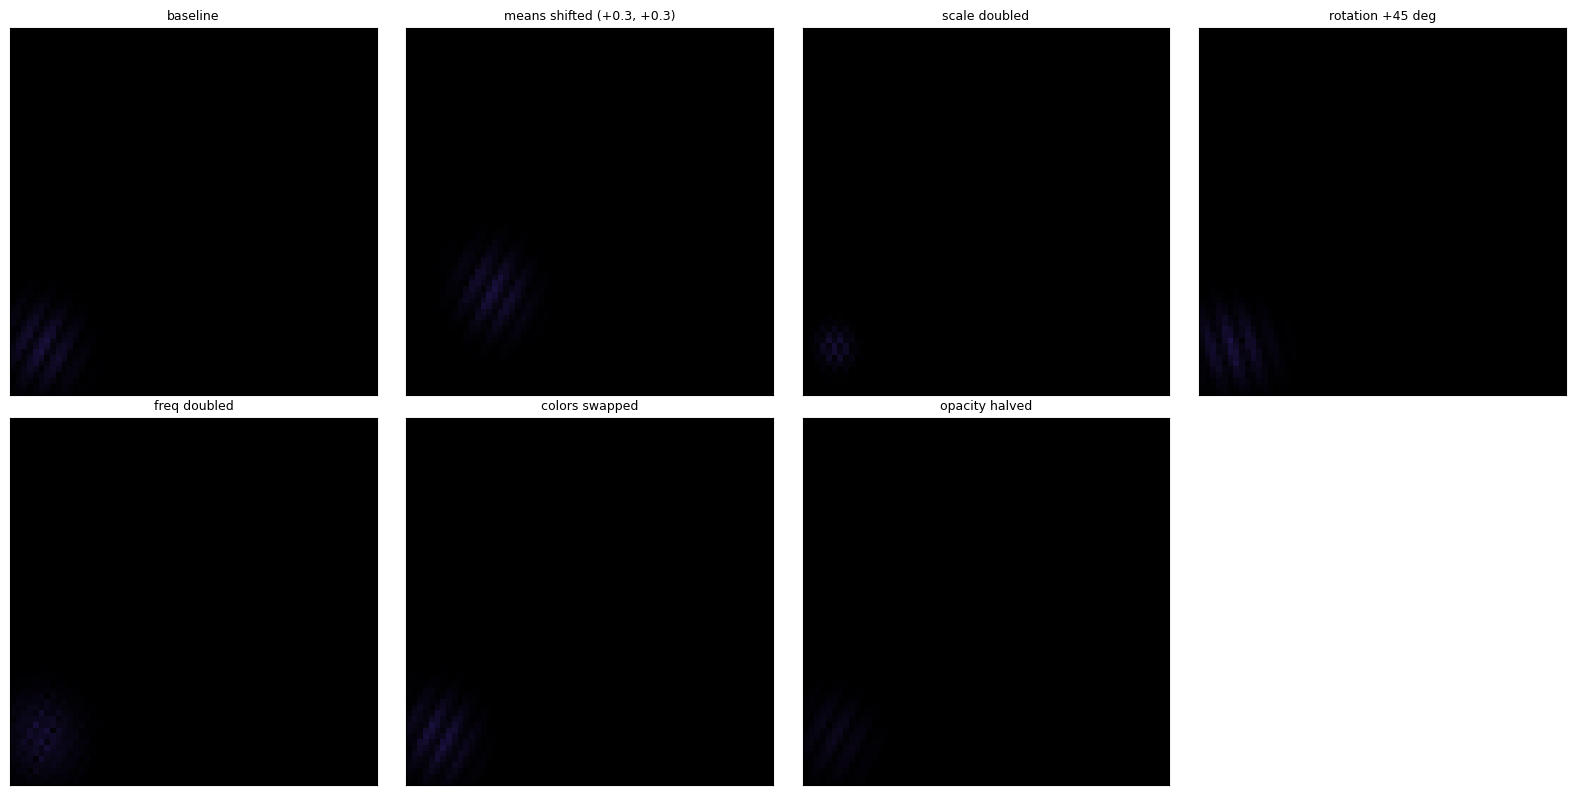

In [17]:
idx = 1
m = model._means.data[idx].clone()
s = model._scales.data[idx].clone()
r = model._rotations.data[idx].clone()
f = model._frequencies.data[idx].clone()
c = model._colors.data[idx].clone()
c2v = model._colors2.data[idx].clone()
o = model._opacities.data[idx].clone()

def shot(mm=m, ss=s, rr=r, ff=f, cc=c, c2v=c2v, oo=o):
    return render_gabor_image(
        KERNEL_SIZE,
        mm[None], ff[None], cc[None], c2v[None], oo[None], ss[None], rr[None], device
    ).clip(0,1).detach().numpy()

variants = [
    ("baseline",                              m, s, r, f, c, c2v, o),
    ("means shifted (+0.3, +0.3)",  m + torch.tensor([0.3,0.3]), s, r, f, c, c2v, o),
    ("scale doubled",                         m, s*2, r, f, c, c2v, o),
    ("rotation +45 deg",                      m, s, r + np.radians(45), f, c, c2v, o),
    ("freq doubled",                          m, s, r, f*2, c, c2v, o),
    ("colors swapped",                        m, s, r, f, c2v, c, o),
    ("opacity halved",                        m, s, r, f, c, c2v, o/2),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (lab, mm, ss, rr, ff, cc, c2v, oo) in zip(axes.ravel(), variants):
    ax.imshow(shot(mm, ss, rr, ff, cc, c2v, oo))
    ax.set_title(lab, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

### 9.8 Weight interpretation quick reference

| Parameter  | Shape (per prim) | Meaning |
|------------|------------------|---------|
| `means`    | `(2,)`           | NDC center `(x, y)` of the patch on `[-1, 1]`, drives the translation |
| `scales`   | `(2,)`           | `(sx, sy)` stretch along each axis, diagonal of the affine matrix |
| `rotations`| scalar (radians) | rotation angle of the patch around its center |
| `frequencies`| `(2,)`         | `(fx, fy)` grating cycles/unit -> stripe spacing/direction |
| `colors`   | `(3,)` RGB       | tint of the bright crest (`* harmonic1`) |
| `colors2`  | `(3,)` RGB       | tint of the dim trough (`* harmonic2`) |
| `opacities`| scalar           | overall alpha multiplier for the whole patch |